# Missing Values

###  MCRA

The data is missing purely by random chance

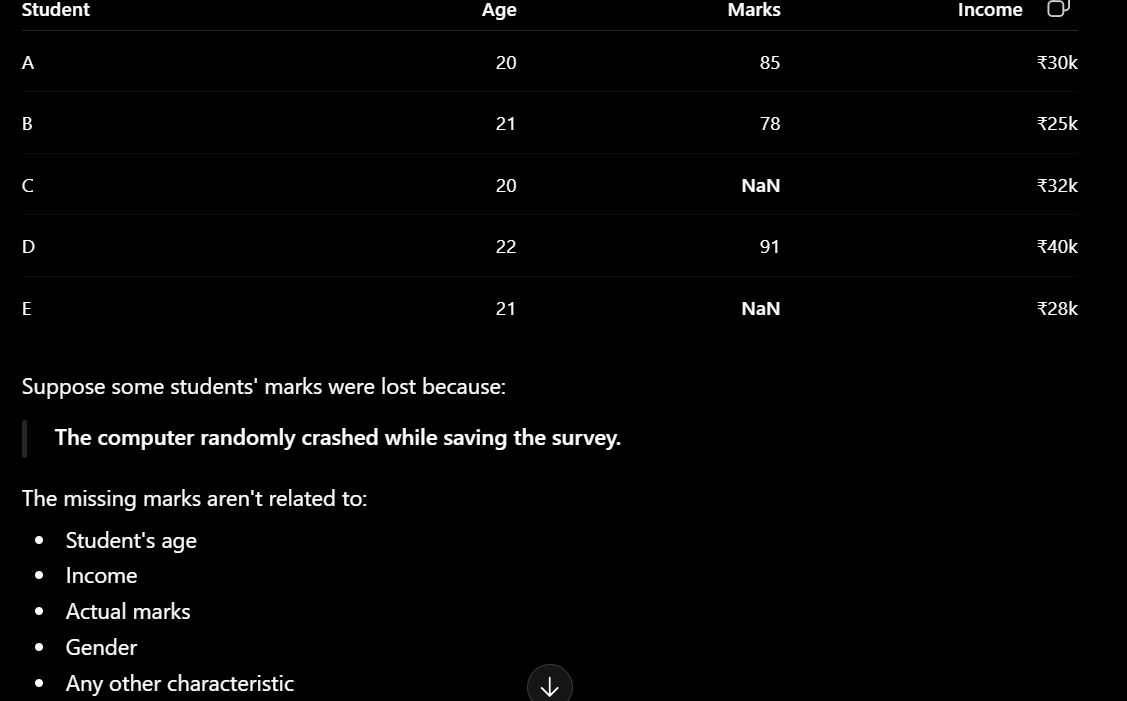

## MAR — Missing At Random

We can explain why something is missing using information that we already have.

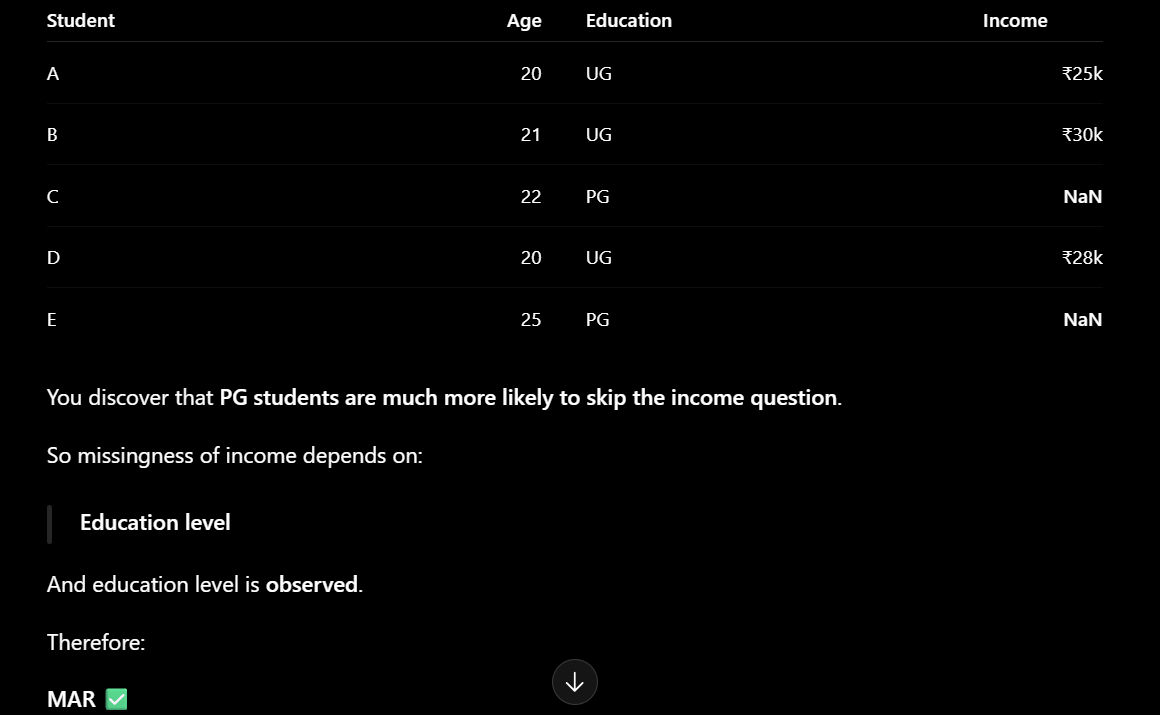

## MNAR — Missing Not At Random

The value is missing because of what that value actually is.

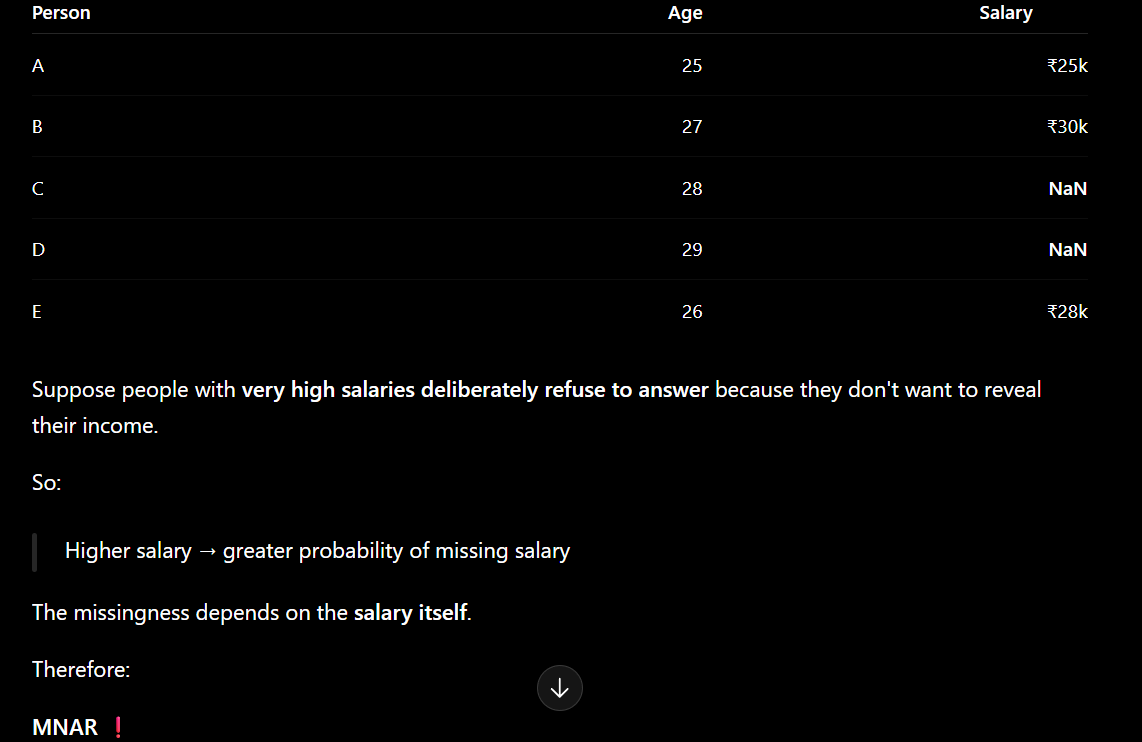

## Dropping vs imputing

Dropping
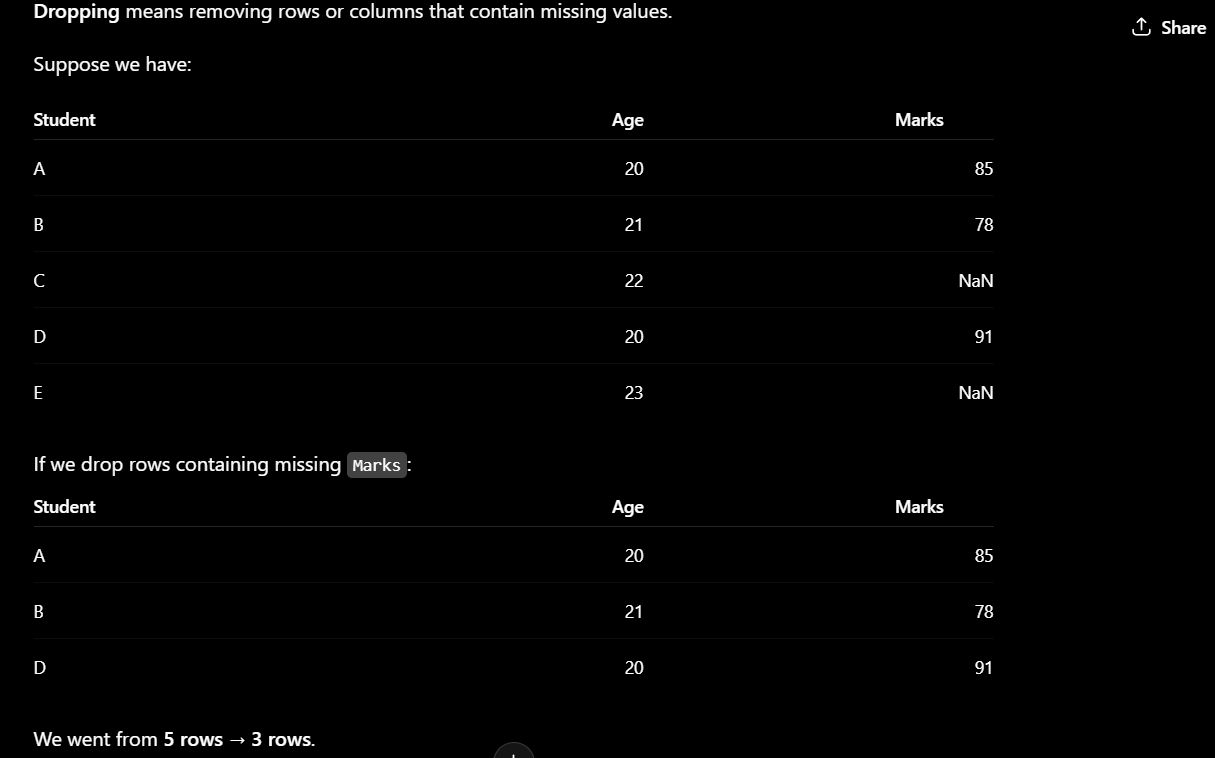

Imputation
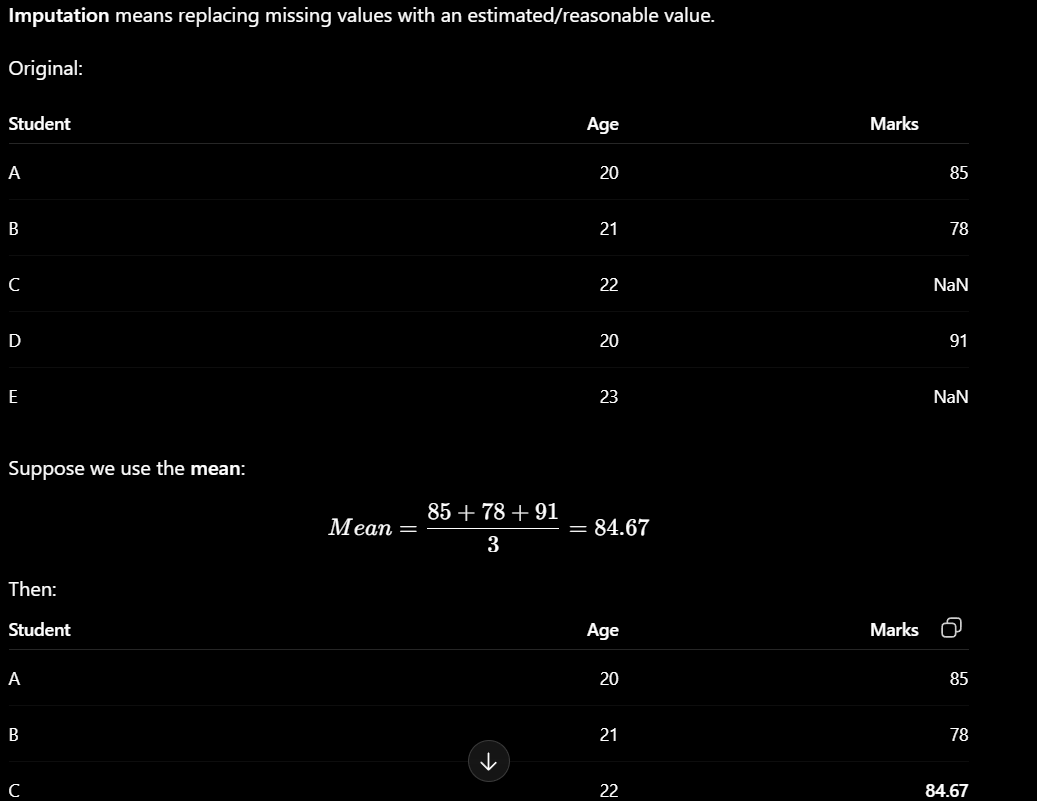

###  When Should You DROP?

### Situation 1 — Very few missing values
- Suppose: **1,000,000 rows**
- Only: **20 rows have missing values**
- Dropping those 20 rows is usually reasonable.  
- **1,000,000 → 999,980** → Almost nothing is lost.

---

### Situation 2 — A column has too many missing values
Example: Missing percentage by column

| Column            | Missing % |
|-------------------|-----------|
| Age               | 2%        |
| Salary            | 5%        |
| Middle Name       | 15%       |
| Previous Employer | 97%       |

- If **Previous Employer** is missing for 97% of observations, imputing it may not make sense.  
- You might consider dropping the column:


df.drop(columns=["Previous_Employer"])

---


### Situation 3 — Missingness makes the row unusable

- Suppose you’re building a model to predict whether a patient has a disease.
- A row has missing values for almost every important feature:

- Age → NaN

- BloodPressure → NaN

- Glucose → NaN

- BMI → NaN

- Cholesterol → 180




### 🔄 When Should You IMPUTE?

### Situation 1 — You have limited data
- Suppose: **100 rows**
- **20 rows contain missing values**
- Dropping 20% of your dataset may be expensive.  
- You might prefer **imputation**.

---

### Situation 2 — The missing feature is important
- Suppose: **Salary → 15% missing**
- Salary is an important feature for your model.  
- Instead of immediately deleting the column, you could:
  - Investigate why it’s missing
  - Consider imputation

---

### Situation 3 — Numerical data has a meaningful distribution
Example:

Age:
- 20
- 21
- 22
- NaN
- 23
- 24


You could use **Mean / Median imputation**:

df["Age"] = df["Age"].fillna(df["Age"].median())

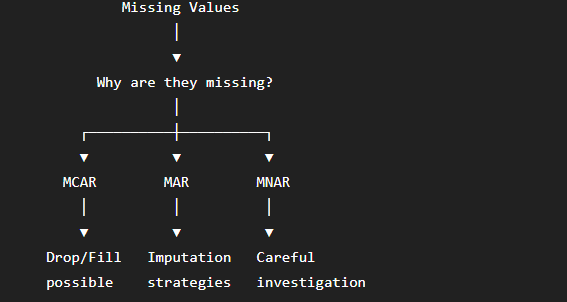


## Mean/Median/Mode imputation

- Mean imputation → use the average
- Median imputation → use the middle value
- Mode imputation → use the most frequent value

### Mean, Median & Mode Imputation

### 1. Mean Imputation 📊

**Mean = Average of all available values**

### When should you use Mean?

Use **mean imputation** when:

- The variable is **numerical**
- Data is **reasonably symmetric**
- There are **few or no extreme outliers**
- Mean represents the data reasonably well

### Example

Height:

| Height |
|---:|
| 165 |
| 170 |
| 168 |
| 172 |
| NaN |
| 169 |

Calculate the mean using the available values:

\[
Mean = \frac{165+170+168+172+169}{5} = 168.8
\]

So the missing value can be replaced with:

**NaN → 168.8**

---

### 2. Median Imputation 📈

**Median = Middle value after sorting the data**

### When should you use Median?

Use **median imputation** when:

- The variable is **numerical**
- Data is **skewed**
- **Outliers** are present
- Median represents the typical value better than mean

### Common Examples

- 💰 Salary
- 🏠 House prices
- 🏥 Medical expenses
- 💵 Income
- 🛒 Transaction amounts

### Example

Suppose salaries are:

```text
20,000
22,000
25,000
27,000
5,00,000
NaN


### 🏷️ Mode Imputation

### What is Mode?
- **Mode** = most frequently occurring value in a dataset.  
- Used for **categorical variables** when imputing missing values.

---

### Example 2 — Student Dataset
| Student | City       |
|---------|------------|
| A       | Chennai    |
| B       | Coimbatore |
| C       | NaN        |
| D       | Chennai    |
| E       | Chennai    |

**Mode:** Chennai



**Replace missing values with Mode:**

| Student | City       |
|---------|------------|
| A       | Chennai    |
| B       | Coimbatore |
| C       | Chennai    |
| D       | Chennai    |
| E       | Chennai    |

---

### ✅ Pandas Implementation
```python
df["City"] = df["City"].fillna(df["City"].mode()[0])


## Forward Fill (FFill) 🔄




**Forward Fill (FFill)** is a missing-value imputation technique that replaces a missing value with the **most recent non-missing value before it**.

### Example

Original:

10  
20  
NaN  
NaN  
50  

After FFill:

10  
20  
20  
20  
50  

### How it works

For every `NaN`:

**NaN → look backward → find the previous valid value → copy that value**

### Pandas

```python
df["column"] = df["column"].ffill()
````

### When to use FFill

* Time-series data
* Sensor readings
* Machine states
* Status information
* Sequential or ordered data

FFill is useful when the **previous value has a meaningful relationship with the missing value**.

### When NOT to use FFill

* Previous value has no relationship with the missing value
* Data is not meaningfully ordered
* Previous value cannot reasonably represent the missing value
* Copying the previous value could introduce bias

### Important

For time-series data, **sort the data chronologically before using FFill**.

```python
df = df.sort_values("Date")
df["column"] = df["column"].ffill()
```

### Group-wise FFill

When data contains different groups, apply FFill separately within each group so that values from one group are not carried into another.

```python
df["Plan"] = df.groupby("Customer")["Plan"].ffill()
```

Example:

| Customer | Plan    |
| -------- | ------- |
| A        | Basic   |
| A        | NaN     |
| A        | NaN     |
| B        | Premium |
| B        | NaN     |

After group-wise FFill:

| Customer | Plan    |
| -------- | ------- |
| A        | Basic   |
| A        | Basic   |
| A        | Basic   |
| B        | Premium |
| B        | Premium |

### FFill vs BFill

| Method    | Uses                 |
| --------- | -------------------- |
| **FFill** | Previous valid value |
| **BFill** | Next valid value     |

FFill:

```text
10
20
NaN
NaN
50
```

↓

```text
10
20
20
20
50
```

BFill:

```text
10
20
NaN
NaN
50
```

↓

```text
10
20
50
50
50
```

### Advantages

* Simple to implement
* Useful for sequential data
* Useful for time-series data
* Preserves existing non-missing values

### Disadvantages

* Can propagate incorrect values
* Can create long sequences of repeated values
* Depends on correct data ordering
* Can introduce bias

### 🧠 Remember

**FFILL = Carry the last known value FORWARD.**

```
```


## Backward Fill (BFill) 🔄


**Backward Fill (BFill)** is a missing-value imputation technique that replaces a missing value with the **next available non-missing value**.

In simple terms:

> **BFill = Carry the next known value backward.**

### Example

Original:

```text
10
20
NaN
NaN
50
````

After BFill:

```text
10
20
50
50
50
```

### How it works

For every `NaN`:

**NaN → look forward → find the next valid value → copy that value backward**

Example:

```text
10
20
NaN  → 50
NaN  → 50
50
```

### Pandas

```python
df["column"] = df["column"].bfill()
```

### When to Use BFill

Use BFill when the **next value has a meaningful relationship with the missing value**.

Useful for:

* Time-series data
* Sequential/ordered data
* Status information
* Sensor readings
* Data where the next value reasonably represents the missing value

### Important ⚠️

If a `NaN` occurs at the **end of the data**, BFill cannot fill it because there is **no future value available**.

Example:

```text
10
20
30
NaN
```

After BFill:

```text
10
20
30
NaN
```

The final `NaN` remains because there is no value after it.

### FFill vs BFill

| Method    | Direction | Uses                 |
| --------- | --------- | -------------------- |
| **FFill** | Forward   | Previous valid value |
| **BFill** | Backward  | Next valid value     |

**FFill:**

```text
10
20
NaN
NaN
50
```

↓

```text
10
20
20
20
50
```

**BFill:**

```text
10
20
NaN
NaN
50
```

↓

```text
10
20
50
50
50
```

### Using Both FFill and BFill

You can use both methods together:

```python
df["column"] = df["column"].ffill().bfill()
```

This can fill missing values that occur at both the beginning and end of the data.

Example:

```text
NaN
10
20
NaN
30
NaN
```

After:

```python
df["column"] = df["column"].ffill().bfill()
```

Result:

```text
10
10
20
20
30
30
```

### Important Rule ⚠️

Do **not** blindly use FFill or BFill.

Before applying them, check:

* Is the data correctly ordered?
* Does the previous/next value logically represent the missing value?
* Could copying the value introduce bias?
* Is the data time-dependent or sequential?

### For Time-Series Data

Always sort by date/time before using FFill or BFill:

```python
df = df.sort_values("Date")
```

Then apply:

```python
df["column"] = df["column"].bfill()
```

### 🧠 Remember

**FFill → Previous value is carried FORWARD**

**BFill → Next value is carried BACKWARD**

```
```


## Problems

1)

In [51]:
import pandas as pd
data = {
    "time": [
        "09:00", "10:00", "11:00",
        "12:00", "13:00", "14:00",
        "15:00"
    ],
    "temperature": [
        30, 31, None,
        None, 34, None, 35
    ]
}

df = pd.DataFrame(data)

In [52]:
df['temperature'].ffill()

0    30.0
1    31.0
2    31.0
3    31.0
4    34.0
5    34.0
6    35.0
Name: temperature, dtype: float64

In [53]:
df['temperature'].bfill()

0    30.0
1    31.0
2    34.0
3    34.0
4    34.0
5    35.0
6    35.0
Name: temperature, dtype: float64

2)

In [54]:
data = {
    "employee": ["A", "B", "C", "D", "E", "F", "G", "H"],
    "age": [22, 25, None, 29, 31, None, 35, 38],
    "salary": [30000, 35000, 40000, None, 45000, None, 50000, 55000],
    "department": [
        "IT", "IT", None, "HR",
        "HR", "HR", "IT", None
    ]
}

df = pd.DataFrame(data)

In [55]:
df

,employee,age,salary,department
0,A,22.0,30000.0,IT
1,B,25.0,35000.0,IT
2,C,NaN,40000.0,NaN
3,D,29.0,NaN,HR
4,E,31.0,45000.0,HR
5,F,NaN,NaN,HR
6,G,35.0,50000.0,IT
7,H,38.0,55000.0,NaN


In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   employee    8 non-null      str    
 1   age         6 non-null      float64
 2   salary      6 non-null      float64
 3   department  6 non-null      str    
dtypes: float64(2), str(2)
memory usage: 388.0 bytes


In [57]:
df.isna()

,employee,age,salary,department
0,False,False,False,False
1,False,False,False,False
2,False,True,False,True
3,False,False,True,False
4,False,False,False,False
5,False,True,True,False
6,False,False,False,False
7,False,False,False,True


In [58]:
df.isna().sum()

employee      0
age           2
salary        2
department    2
dtype: int64

In [59]:
# gives percenatage of value missing from each row
df.isna().mean() *100

employee       0.0
age           25.0
salary        25.0
department    25.0
dtype: float64

In [60]:
# for age we have to use median values since its increasing
df["age"] = df["age"].interpolate(method="linear")

In [61]:
df['age']

0    22.0
1    25.0
2    27.0
3    29.0
4    31.0
5    33.0
6    35.0
7    38.0
Name: age, dtype: float64

In [62]:
# salary also increasing so we have to use median again
df["salary"] = df["salary"].interpolate(method="linear")
df['salary']

0    30000.0
1    35000.0
2    40000.0
3    42500.0
4    45000.0
5    47500.0
6    50000.0
7    55000.0
Name: salary, dtype: float64

In [63]:
# for department its not related to age and salary both 
# so we can simply use the ffill or bfill or both at this case
df['department']= df['department'].bfill().ffill()

In [64]:
df.isna().mean() *100

employee      0.0
age           0.0
salary        0.0
department    0.0
dtype: float64

3)

In [2]:
import pandas as pd
df = pd.read_csv('data/raw/titanic.csv')

In [3]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
pd.set_option("display.max_columns", 15)
pd.set_option("display.max_rows", 450)

In [5]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
df.isna().mean() * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.574163
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.239234
Cabin          78.229665
Embarked        0.000000
dtype: float64

In [7]:
df.groupby("Pclass")["Cabin"].apply(lambda x: x.isna().mean())

Pclass
1    0.252336
2    0.924731
3    0.981651
Name: Cabin, dtype: float64

In [8]:
df.groupby("Pclass")["Fare"].mean()

Pclass
1    94.280297
2    22.202104
3    12.459678
Name: Fare, dtype: float64


### GROUPBY FOR MISSING-VALUE ANALYSIS

### What is `groupby()`?

`groupby()` divides the dataset into groups based on a column and
allows us to perform calculations separately for each group.

### Basic Syntax

```python
df.groupby("group_column")["value_column"].mean()
````

---

### Example 1 — Average Fare by Passenger Class

```python
df.groupby("Pclass")["Fare"].mean()
```

This means:

> Calculate the average `Fare` separately for each `Pclass`.

Example output:

```text
Pclass
1    94.28
2    22.20
3    12.46
```

Interpretation:

* 1st class → highest average fare
* 2nd class → lower average fare
* 3rd class → lowest average fare

---

### Example 2 — Check Missing Cabin Values by Pclass

```python
df.groupby("Pclass")["Cabin"].apply(
    lambda x: x.isna().mean()
)
```

This means:

> Calculate the proportion of missing `Cabin` values separately
> for each `Pclass`.

Example:

```text
Pclass
1    0.252
2    0.925
3    0.982
```

Convert to percentage:

```python
df.groupby("Pclass")["Cabin"].apply(
    lambda x: x.isna().mean() * 100
)
```

Example interpretation:

```text
1st class → ~25% Cabin missing
2nd class → ~92% Cabin missing
3rd class → ~98% Cabin missing
```

Therefore, Cabin missingness varies strongly across passenger classes.

---

### Why use `isna().mean()`?

`isna()` identifies missing values:

```text
False → value exists
True  → value is missing
```

Pandas treats:

```text
False = 0
True  = 1
```

Therefore:

```python
x.isna().mean()
```

gives the proportion of missing values.

And:

```python
x.isna().mean() * 100
```

gives the percentage of missing values.

---

### GroupBy for MAR Investigation

`groupby()` can help investigate whether missingness
depends on an observed variable.

Example:

```python
df.groupby("Pclass")["Cabin"].apply(
    lambda x: x.isna().mean() * 100
)
```

If missingness is very different between groups:

```text
Pclass → Cabin missingness
```

then `Pclass` may be related to why `Cabin` is missing.

Since `Pclass` is observed, this provides evidence that
the missingness may be MAR.

IMPORTANT:
This does NOT prove that the data is MAR.
It only provides evidence supporting a MAR hypothesis.

---

### Other Common GroupBy Operations

```python
df.groupby("Pclass")["Fare"].mean()
df.groupby("Pclass")["Fare"].median()
df.groupby("Pclass")["Fare"].sum()
df.groupby("Pclass")["Fare"].count()
df.groupby("Pclass")["Fare"].min()
df.groupby("Pclass")["Fare"].max()
```

---

### Key Idea

```text
groupby()
    ↓
Split data into groups
    ↓
Perform calculation for each group
    ↓
Compare the groups
    ↓
Find patterns and relationships
```

### For missing-value analysis:

```python
df.groupby("Group")["Column"].apply(
    lambda x: x.isna().mean()
)
```

means:

> "Find the percentage of missing values in `Column`
> separately for each `Group`."


In [9]:
filt = ( df['Pclass'] == 1)

In [10]:
df[filt].sort_values(by='Cabin')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
208,1100,1,1,"Rosenbaum, Miss. Edith Louise",female,33.0,0,0,PC 17613,27.7208,A11,C
331,1223,0,1,"Dulles, Mr. William Crothers",male,39.0,0,0,PC 17580,29.7000,A18,C
28,920,0,1,"Brady, Mr. John Bertram",male,41.0,0,0,113054,30.5000,A21,S
112,1004,1,1,"Evans, Miss. Edith Corse",female,36.0,0,0,PC 17531,31.6792,A29,C
374,1266,1,1,"Dodge, Mrs. Washington (Ruth Vidaver)",female,54.0,1,1,33638,81.8583,A34,S
293,1185,0,1,"Dodge, Dr. Washington",male,53.0,1,1,33638,81.8583,A34,S
46,938,0,1,"Chevre, Mr. Paul Romaine",male,45.0,0,0,PC 17594,29.7000,A9,C
166,1058,0,1,"Brandeis, Mr. Emil",male,48.0,0,0,PC 17591,50.4958,B10,C
215,1107,0,1,"Head, Mr. Christopher",male,42.0,0,0,113038,42.5000,B11,S
390,1282,0,1,"Payne, Mr. Vivian Ponsonby",male,23.0,0,0,12749,93.5000,B24,S


In [11]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [12]:
import numpy as np
filt = (df['Age'].isna() )

In [13]:
df.loc[filt]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
10,902,0,3,"Ilieff, Mr. Ylio",male,NaN,0,0,349220,7.8958,NaN,S
22,914,1,1,"Flegenheim, Mrs. Alfred (Antoinette)",female,NaN,0,0,PC 17598,31.6833,NaN,S
29,921,0,3,"Samaan, Mr. Elias",male,NaN,2,0,2662,21.6792,NaN,C
33,925,1,3,"Johnston, Mrs. Andrew G (Elizabeth Lily"" Watson)""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
36,928,1,3,"Roth, Miss. Sarah A",female,NaN,0,0,342712,8.0500,NaN,S
39,931,0,3,"Hee, Mr. Ling",male,NaN,0,0,1601,56.4958,NaN,S
41,933,0,1,"Franklin, Mr. Thomas Parham",male,NaN,0,0,113778,26.5500,D34,S
47,939,0,3,"Shaughnessy, Mr. Patrick",male,NaN,0,0,370374,7.7500,NaN,Q
54,946,0,2,"Mangiavacchi, Mr. Serafino Emilio",male,NaN,0,0,SC/A.3 2861,15.5792,NaN,C
58,950,0,3,"Davison, Mr. Thomas Henry",male,NaN,1,0,386525,16.1000,NaN,S


In [14]:
# For age missing persons there are totally 86 persons mosts from the 3rd class i guess
# this is directly related to price because they cannot afford it
# SO age missing value is MAR in this case because price is been related here

df.groupby("Pclass")["Age"].apply(lambda x: x.isna().mean())

Pclass
1    0.084112
2    0.053763
3    0.330275
Name: Age, dtype: float64

In [15]:
df['Age'].median()

np.float64(27.0)

In [16]:
df['Age'].mean()

np.float64(30.272590361445783)

In [17]:
# there is no need to drop the age values here
# we can just use mean
# because from values we see 27 for median and 30 for mean there is no outlier so we can just use average value here

In [18]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [19]:
# cabin is approximately 78 percent Nan
# and mainly Pclass 2 and 3 are empty here 
# because of the fare price
# we cannot impute the values since once allocated we cannot use the same again
# because of high missing values and cannot use again we cand drop cabbin column
# since its related to price mostly because of pclass we can classify this as MAR

In [20]:
filt= (df['Fare'].isna())

In [21]:
df.loc[filt]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,0,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [22]:
# for fare only one is missing here
# this one data doesnt value that much
# but he traveeled in titanic so we should not delete it
# we have to keep it

In [23]:
pclass_3_mean = df.loc[df["Pclass"] == 3, "Fare"].mean()

In [24]:
# we can simply replace the fare price of that particular passenger

In [25]:
df_copy = df.copy()

In [26]:
df_copy.drop(columns=['Cabin'],inplace=True)

In [27]:
df_copy['Age'] = df['Age'].fillna(df['Age'].mean())

In [28]:
df_copy['Fare'] = df['Fare'].fillna(pclass_3_mean)

In [29]:
df_copy

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.50000,0,0,330911,7.829200,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.00000,1,0,363272,7.000000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.00000,0,0,240276,9.687500,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.00000,0,0,315154,8.662500,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.00000,1,1,3101298,12.287500,S
5,897,0,3,"Svensson, Mr. Johan Cervin",male,14.00000,0,0,7538,9.225000,S
6,898,1,3,"Connolly, Miss. Kate",female,30.00000,0,0,330972,7.629200,Q
7,899,0,2,"Caldwell, Mr. Albert Francis",male,26.00000,1,1,248738,29.000000,S
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.00000,0,0,2657,7.229200,C
9,901,0,3,"Davies, Mr. John Samuel",male,21.00000,2,0,A/4 48871,24.150000,S


In [30]:
print("Original Dataset")
print("Shape",df.shape)
print(df.isna().mean()*100)
print()
print("Modified Dataset")
print("Shape",df_copy.shape)
print(df_copy.isna().mean()*100)

Original Dataset
Shape (418, 12)
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.574163
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.239234
Cabin          78.229665
Embarked        0.000000
dtype: float64

Modified Dataset
Shape (418, 11)
PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64


In [31]:
df_copy.to_csv('data/processed/modified_titanic.csv')

In [36]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

df["Age_Group"] = pd.cut(df["Age"], bins=bins)
df['Age_Group'].value_counts(dropna= False)

Age_Group
(20.0, 30.0]     131
NaN               86
(30.0, 40.0]      55
(10.0, 20.0]      47
(40.0, 50.0]      46
(0.0, 10.0]       22
(50.0, 60.0]      20
(60.0, 70.0]      10
(70.0, 80.0]       1
(80.0, 90.0]       0
(90.0, 100.0]      0
Name: count, dtype: int64